In [1]:
import MDAnalysis as mda
from numpy import *
import os
from pylab import *
import MDAnalysis.analysis.distances
import MDAnalysis.analysis.rms
from MDAnalysis.analysis import align
import glob
#import umap
import scipy.stats
import sklearn
import sklearn.decomposition
import sklearn.preprocessing
import pandas as pd
import seaborn as sns
from MDAnalysis.analysis.hydrogenbonds.hbond_analysis import HydrogenBondAnalysis as HBA

In [39]:
import os
EQPOINT=0

systemFolders = glob.glob("*t5a*/")

systemgros=[]
systemtprs=[]
systemtrjs=[]
for i in range(len(systemFolders)):
    systemgros.append(sorted(glob.glob(systemFolders[i]+"*.gro")))
    systemtprs.append(sorted(glob.glob(systemFolders[i]+"*.tpr")))
    systemtrjs.append(sorted(glob.glob(systemFolders[i]+"*.xtc")))


    
    
threeColor=["#0A732D","#332288","#882255"]
colourScheme= threeColor
system_names = ["rhT5A","T5A","T5AR332P"]
systems=[]
for i in range(len(systemgros)):
    sub=[]
    for j in range(len(systemtprs[i])):
        # When using TPRs, residues are indexed from 1; so we need to add in the first residue, 1 - 1 + first resid=first resid
        firstres = mda.Universe(systemgros[i][j]).residues.resids[0]-1
        tu = mda.Universe(systemtprs[i][j],systemtrjs[i][j])
        tu.residues.resids +=firstres
                          
        sub.append(tu)
        
    systems.append(sub)

proteins=[]
#proteins
for i in range(len(systems)):
    sub=[]
    for j in range(len(systems[i])):
        sub.append(systems[i][j].select_atoms("protein"))
    proteins.append(sub)


bodys=[]
# rhesus v1 is 326-349
# Human v1 is 324-345
huloopstring = "resid 324:345"
rhloopstring = "resid 326:349"
system_loop_strings = [rhloopstring,huloopstring,huloopstring]
for i in range(len(systems)):
    sub = []
    for j in range(len(systems[i])):
        sub.append(systems[i][j].select_atoms("protein and not ("+system_loop_strings[i]+")"))
        
    bodys.append(sub)
    
    
v1s=[]
# rhesus v1 is 326-349
# Human v1 is 324-345
huloopstring = "resid 324:345"
rhloopstring = "resid 326:349"
system_loop_strings = [rhloopstring,huloopstring,huloopstring]
for i in range(len(systems)):
    sub = []
    for j in range(len(systems[i])):
        sub.append(systems[i][j].select_atoms("protein and "+system_loop_strings[i]))
        
    v1s.append(sub)                   
                   

array([  292,   293,   294, ..., 13391, 13392, 13393])

In [28]:
# We used this to find which ones wre corrupted
#for i in range(len(systems)):
#    print(system_names[i])
#    for j in range(len(systems[i])):
#        print(len(systems[i][j].trajectory))

In [4]:
def getRgs(systems,datasets):
    allrgs=[]
    rgs=[]
    stderrs=[]
    for i in range(len(datasets)):
        subrgs=[]
        for j in range(len(datasets[i])):
            rg=[]
            for ts in systems[i][j].trajectory: 
                rg.append((systems[i][j].trajectory.time, datasets[i][j].radius_of_gyration())[1])
            subrgs.append(rg)
        allrgs.append(subrgs)

    return allrgs

allrgs = getRgs(systems,proteins)

systemrgs=[]
for i in range(len(allrgs)):
    trjrgs=[]
    for j in range(len(allrgs[i])):
        trjrgs.append(mean(allrgs[i][j]))
    systemrgs.append(trjrgs)

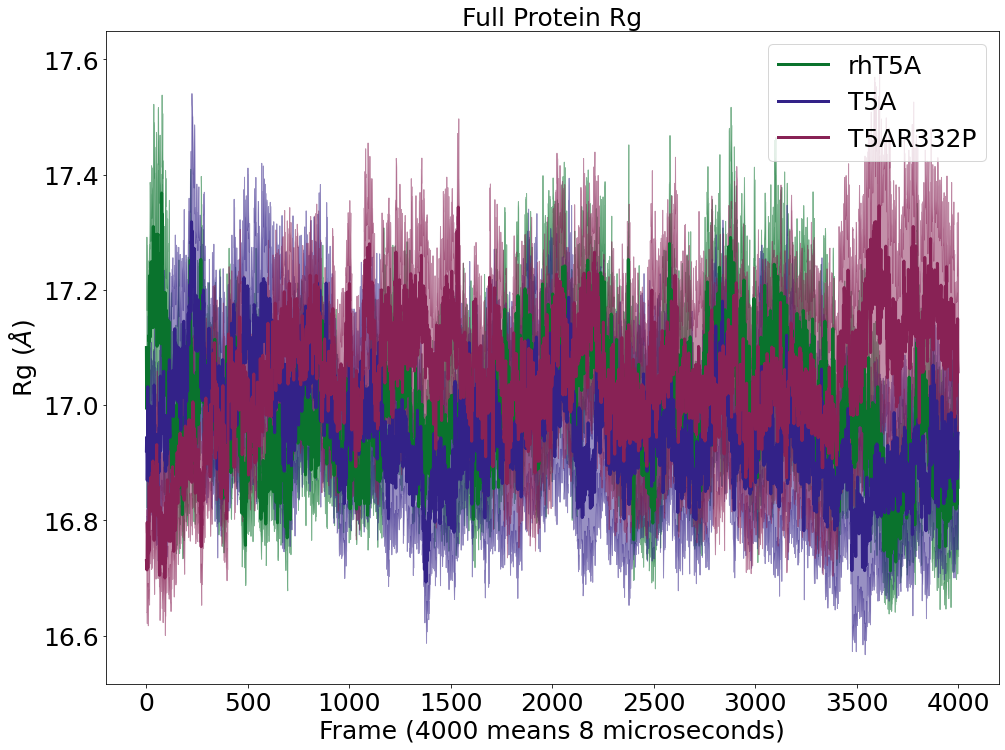

In [44]:
figure(figsize = (16,12))    
plot(mean(allrgs[0],axis = 0),color = colourScheme[0],linewidth = 3,label = system_names[0])
fill_between(arange(4001),mean(allrgs[0],axis = 0)+scipy.stats.sem(allrgs[0],axis = 0),mean(allrgs[0],axis = 0)-scipy.stats.sem(allrgs[0],axis = 0),color = colourScheme[0],alpha = 0.5)

plot(mean(allrgs[1],axis = 0),color = colourScheme[1],linewidth = 3,label = system_names[1])
fill_between(arange(4001),mean(allrgs[1],axis = 0)+scipy.stats.sem(allrgs[1],axis = 0),mean(allrgs[1],axis = 0)-scipy.stats.sem(allrgs[1],axis = 0),color = colourScheme[1],alpha = 0.5)


plot(mean(allrgs[2],axis = 0),color = colourScheme[2],linewidth = 3,label = system_names[2])
fill_between(arange(4001),mean(allrgs[2],axis = 0)+scipy.stats.sem(allrgs[2],axis = 0),mean(allrgs[2],axis = 0)-scipy.stats.sem(allrgs[2],axis = 0),color = colourScheme[2],alpha = 0.5)






xlabel("Frame (4000 means 8 microseconds)",fontsize = 25)
ylabel("Rg ($\AA$)",fontsize = 25)
title("Full Protein Rg",fontsize = 25)
xticks(fontsize = 25)
yticks(fontsize = 25)
legend(fontsize = 25)

C:\Users\Liam\anaconda3\envs\mda2\lib\site-packages\matplotlib\tight_bbox.py:71: RuntimeWarning: divide by zero encountered in double_scalars
  fig.patch.set_bounds(x0 / w1, y0 / h1,
C:\Users\Liam\anaconda3\envs\mda2\lib\site-packages\matplotlib\tight_bbox.py:72: RuntimeWarning: divide by zero encountered in double_scalars
  fig.bbox.width / w1, fig.bbox.height / h1)
C:\Users\Liam\anaconda3\envs\mda2\lib\site-packages\matplotlib\patches.py:749: RuntimeWarning: invalid value encountered in double_scalars
  x1 = self.convert_xunits(self._x0 + self._width)
C:\Users\Liam\anaconda3\envs\mda2\lib\site-packages\matplotlib\patches.py:750: RuntimeWarning: invalid value encountered in double_scalars
  y1 = self.convert_yunits(self._y0 + self._height)


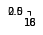

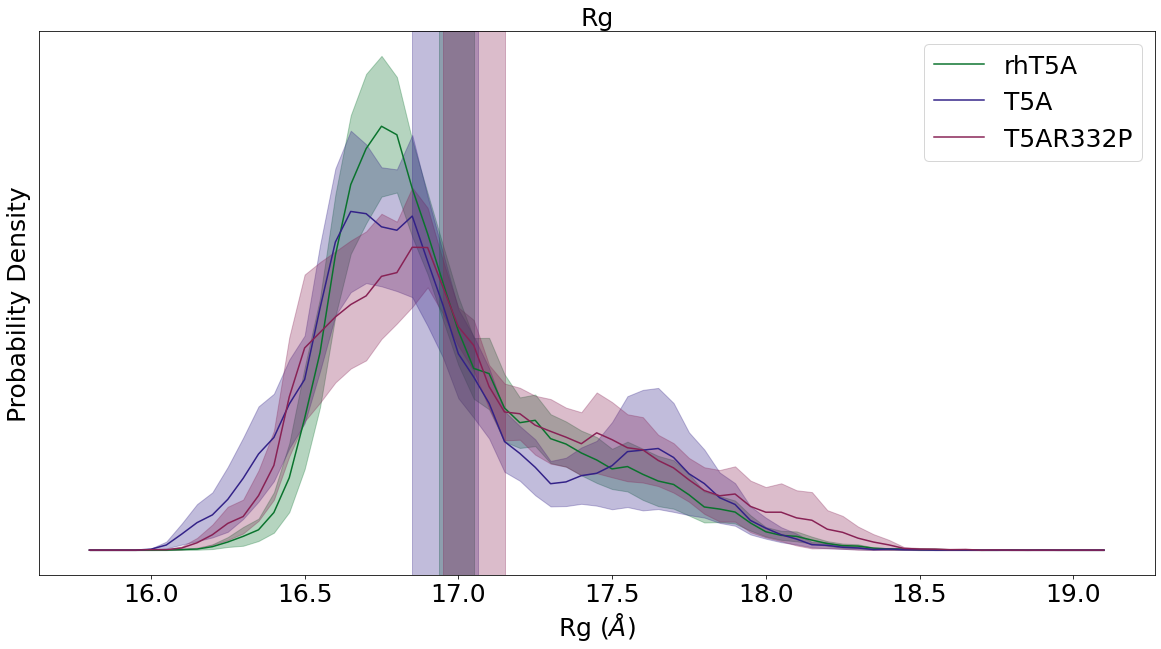

In [7]:
rgRange=arange(15.8,19.2,.05)

all_importantrg_histsca=[]
figure(figsize = (0,0))

for i in range(len(allrgs)):
    sub=[]
    for j in range(len(allrgs[i])):
        a=hist(allrgs[i][j][EQPOINT:],bins = rgRange,density = True,alpha = 0.8,color= colourScheme[0],label = system_names[0])
        sub.append(a[0])
    all_importantrg_histsca.append(sub)
    
system_avg_importantrgsca=[]
system_sem_importantrgsca=[]

for i in range(len(all_importantrg_histsca)):
    system_avg_importantrgsca.append(mean(all_importantrg_histsca[i],axis = 0))
    system_sem_importantrgsca.append(scipy.stats.sem(all_importantrg_histsca[i],axis = 0))
    
    
    
    
trjmeans = []
for i in range(len(allrgs)):
    sub = []
    for j in range(len(allrgs[i])):
        sub.append(mean(allrgs[i][j]))
    trjmeans.append(sub)
    
actualMean= [mean(trjmeans[0]),mean(trjmeans[1]),mean(trjmeans[2])]
actualSem = [scipy.stats.sem(trjmeans[0]),scipy.stats.sem(trjmeans[1]),scipy.stats.sem(trjmeans[2])]


figure(figsize = (20,10))
plot(rgRange[:-1],system_avg_importantrgsca[0],color = colourScheme[0],label = system_names[0])
plot(rgRange[:-1],system_avg_importantrgsca[1],color = colourScheme[1],label = system_names[1])
plot(rgRange[:-1],system_avg_importantrgsca[2],color = colourScheme[2],label = system_names[2])


fill_between(rgRange[:-1], system_avg_importantrgsca[0] - system_sem_importantrgsca[0],system_avg_importantrgsca[0] + system_sem_importantrgsca[0],color = colourScheme[0],alpha = 0.3)
fill_between(rgRange[:-1], system_avg_importantrgsca[1] - system_sem_importantrgsca[1],system_avg_importantrgsca[1] + system_sem_importantrgsca[1],color = colourScheme[1],alpha = 0.3)
fill_between(rgRange[:-1], system_avg_importantrgsca[2] - system_sem_importantrgsca[2],system_avg_importantrgsca[2] + system_sem_importantrgsca[2],color = colourScheme[2],alpha = 0.3)


xlabel("Rg ($\AA$)",fontsize = 25)
ylabel("Probability Density",fontsize = 25)
title("Rg",fontsize = 25)
xticks(fontsize = 25)
yticks([],fontsize = 25)

legend(fontsize = 25)


axvspan(actualMean[0] - actualSem[0],actualMean[0]+actualSem[0], color = colourScheme[0], alpha = 0.3)
axvspan(actualMean[1] - actualSem[1],actualMean[1]+actualSem[1], color = colourScheme[1], alpha = 0.3)
axvspan(actualMean[2] - actualSem[2],actualMean[2]+actualSem[2], color = colourScheme[2], alpha = 0.3)




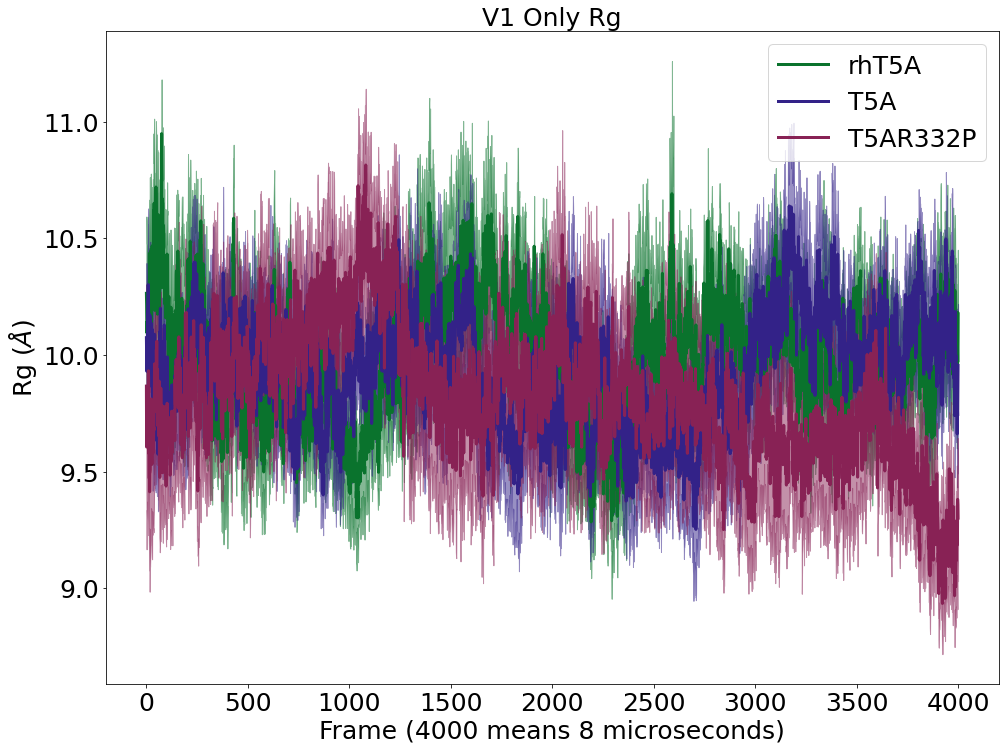

In [41]:
v1rgs = getRgs(systems,v1s)

v1systemrgs=[]
for i in range(len(v1rgs)):
    trjrgs=[]
    for j in range(len(v1rgs[i])):
        trjrgs.append(mean(v1rgs[i][j]))
    v1systemrgs.append(trjrgs)
    
figure(figsize = (16,12))    
plot(mean(v1rgs[0],axis = 0),color = colourScheme[0],linewidth = 3,label = system_names[0])
fill_between(arange(4001),mean(v1rgs[0],axis = 0)+scipy.stats.sem(v1rgs[0],axis = 0),mean(v1rgs[0],axis = 0)-scipy.stats.sem(v1rgs[0],axis = 0),color = colourScheme[0],alpha = 0.5)

plot(mean(v1rgs[1],axis = 0),color = colourScheme[1],linewidth = 3,label = system_names[1])
fill_between(arange(4001),mean(v1rgs[1],axis = 0)+scipy.stats.sem(v1rgs[1],axis = 0),mean(v1rgs[1],axis = 0)-scipy.stats.sem(v1rgs[1],axis = 0),color = colourScheme[1],alpha = 0.5)


plot(mean(v1rgs[2],axis = 0),color = colourScheme[2],linewidth = 3,label = system_names[2])
fill_between(arange(4001),mean(v1rgs[2],axis = 0)+scipy.stats.sem(v1rgs[2],axis = 0),mean(v1rgs[2],axis = 0)-scipy.stats.sem(v1rgs[2],axis = 0),color = colourScheme[2],alpha = 0.5)






xlabel("Frame (4000 means 8 microseconds)",fontsize = 25)
ylabel("Rg ($\AA$)",fontsize = 25)
title("V1 Only Rg",fontsize = 25)
xticks(fontsize = 25)
yticks(fontsize = 25)
legend(fontsize = 25)

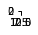

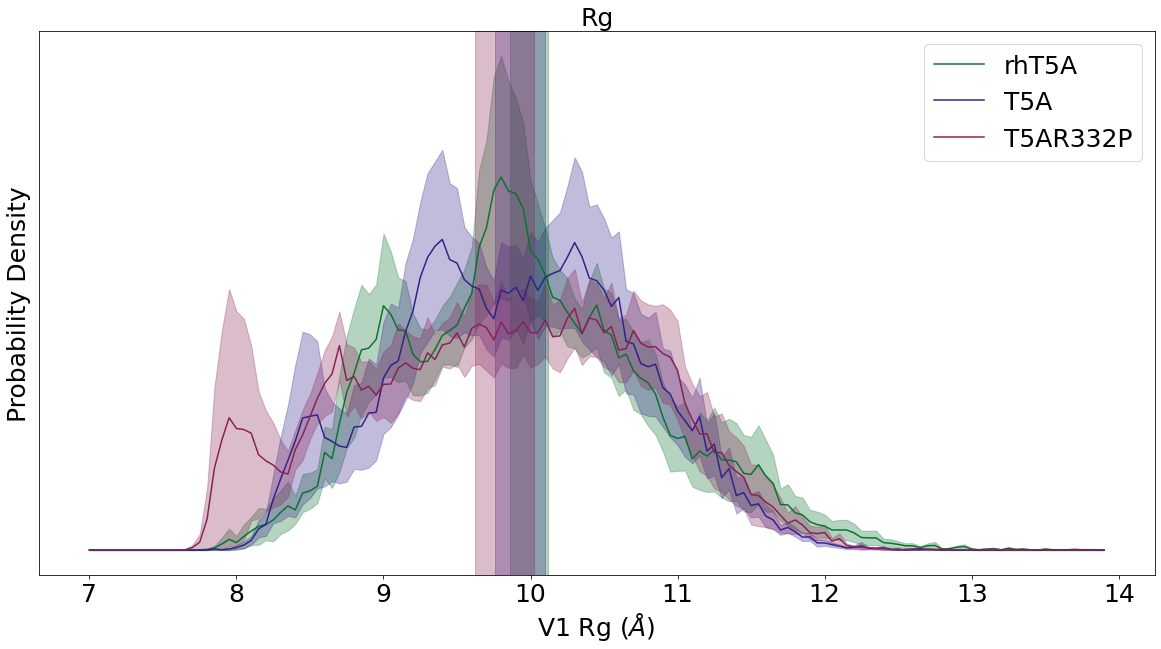

In [49]:
rgRange=arange(7.,14.,.05)

all_importantrg_histsca=[]
figure(figsize = (0,0))

for i in range(len(v1rgs)):
    sub=[]
    for j in range(len(v1rgs[i])):
        a=hist(v1rgs[i][j][EQPOINT:],bins = rgRange,density = True,alpha = 0.8,color= colourScheme[0],label = system_names[0])
        sub.append(a[0])
    all_importantrg_histsca.append(sub)
    
system_avg_importantrgsca=[]
system_sem_importantrgsca=[]

for i in range(len(all_importantrg_histsca)):
    system_avg_importantrgsca.append(mean(all_importantrg_histsca[i],axis = 0))
    system_sem_importantrgsca.append(scipy.stats.sem(all_importantrg_histsca[i],axis = 0))
    
    
    
    
trjmeans = []
for i in range(len(v1rgs)):
    sub = []
    for j in range(len(v1rgs[i])):
        sub.append(mean(v1rgs[i][j]))
    trjmeans.append(sub)
    
actualMean= [mean(trjmeans[0]),mean(trjmeans[1]),mean(trjmeans[2])]
actualSem = [scipy.stats.sem(trjmeans[0]),scipy.stats.sem(trjmeans[1]),scipy.stats.sem(trjmeans[2])]


figure(figsize = (20,10))
plot(rgRange[:-1],system_avg_importantrgsca[0],color = colourScheme[0],label = system_names[0])
plot(rgRange[:-1],system_avg_importantrgsca[1],color = colourScheme[1],label = system_names[1])
plot(rgRange[:-1],system_avg_importantrgsca[2],color = colourScheme[2],label = system_names[2])


fill_between(rgRange[:-1], system_avg_importantrgsca[0] - system_sem_importantrgsca[0],system_avg_importantrgsca[0] + system_sem_importantrgsca[0],color = colourScheme[0],alpha = 0.3)
fill_between(rgRange[:-1], system_avg_importantrgsca[1] - system_sem_importantrgsca[1],system_avg_importantrgsca[1] + system_sem_importantrgsca[1],color = colourScheme[1],alpha = 0.3)
fill_between(rgRange[:-1], system_avg_importantrgsca[2] - system_sem_importantrgsca[2],system_avg_importantrgsca[2] + system_sem_importantrgsca[2],color = colourScheme[2],alpha = 0.3)


xlabel("V1 Rg ($\AA$)",fontsize = 25)
ylabel("Probability Density",fontsize = 25)
title("Rg",fontsize = 25)
xticks(fontsize = 25)
yticks([],fontsize = 25)

legend(fontsize = 25)


axvspan(actualMean[0] - actualSem[0],actualMean[0]+actualSem[0], color = colourScheme[0], alpha = 0.3)
axvspan(actualMean[1] - actualSem[1],actualMean[1]+actualSem[1], color = colourScheme[1], alpha = 0.3)
axvspan(actualMean[2] - actualSem[2],actualMean[2]+actualSem[2], color = colourScheme[2], alpha = 0.3)




C:\Users\Liam\anaconda3\envs\mda2\lib\site-packages\MDAnalysis\analysis\rms.py:710: DeprecationWarning: The `rmsd` attribute was deprecated in MDAnalysis 2.0.0 and will be removed in MDAnalysis 3.0.0. Please use `results.rmsd` instead.
  warnings.warn(wmsg, DeprecationWarning)


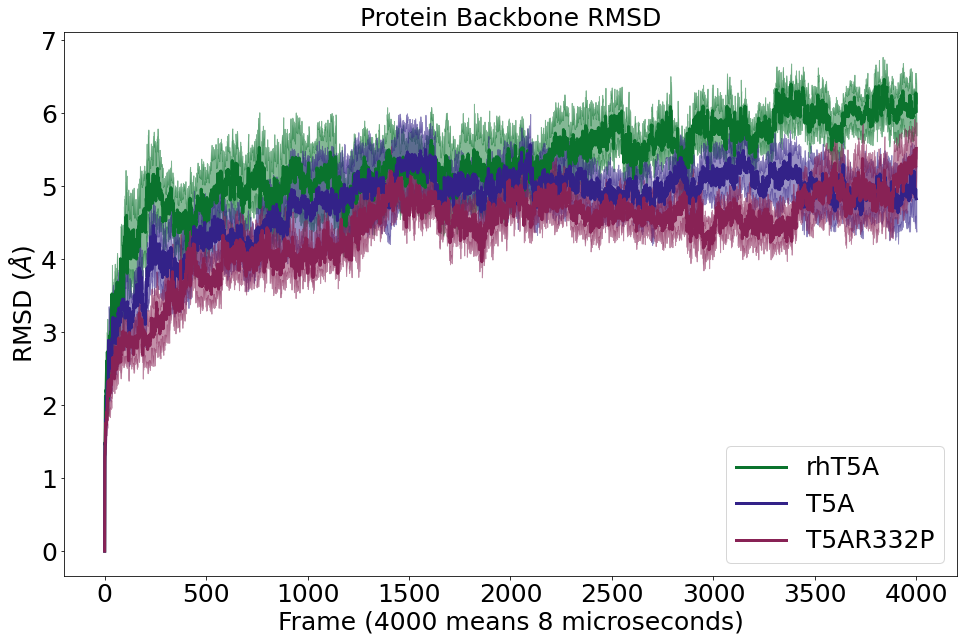

In [9]:
def getRMSD(u,selstring= "backbone"):
    ref = u

    import MDAnalysis.analysis.rms

    R = MDAnalysis.analysis.rms.RMSD(u, ref,
               select=selstring)             # superimpose on whole backbone of the whole protein)                                    # NMP
    R.run()

    rmsd = R.rmsd.T   # transpose makes it easier for plotting
    time = rmsd[1]

    return rmsd[2]

fullrmsds=[]
figure(figsize = (16,10))
for i in range(len(systems)):
    sub=[]
    for j in range(len(systems[i])):
        if i == 0:
            c = colourScheme[0]
        if i==1:
            c = colourScheme[1]
        if i == 2:
            c = colourScheme[2]
            
        sub.append(getRMSD(systems[i][j],"backbone"))
        #plot(sub[j],color = c,alpha = 0.3)
    fullrmsds.append(sub)
plot(mean(fullrmsds[0],axis = 0),color = colourScheme[0],linewidth = 3,label = system_names[0])
fill_between(arange(4001),mean(fullrmsds[0],axis = 0)+scipy.stats.sem(fullrmsds[0],axis = 0),mean(fullrmsds[0],axis = 0)-scipy.stats.sem(fullrmsds[0],axis = 0),color = colourScheme[0],alpha = 0.5)

plot(mean(fullrmsds[1],axis = 0),color = colourScheme[1],linewidth = 3,label = system_names[1])
fill_between(arange(4001),mean(fullrmsds[1],axis = 0)+scipy.stats.sem(fullrmsds[1],axis = 0),mean(fullrmsds[1],axis = 0)-scipy.stats.sem(fullrmsds[1],axis = 0),color = colourScheme[1],alpha = 0.5)


plot(mean(fullrmsds[2],axis = 0),color = colourScheme[2],linewidth = 3,label = system_names[2])
fill_between(arange(4001),mean(fullrmsds[2],axis = 0)+scipy.stats.sem(fullrmsds[2],axis = 0),mean(fullrmsds[2],axis = 0)-scipy.stats.sem(fullrmsds[2],axis = 0),color = colourScheme[2],alpha = 0.5)






xlabel("Frame (4000 means 8 microseconds)",fontsize = 25)
ylabel("RMSD ($\AA$)",fontsize = 25)
title("Protein Backbone RMSD",fontsize = 25)
xticks(fontsize = 25)
yticks(fontsize = 25)
legend(fontsize = 25)

In [32]:
def getRMSD(u,selstring= "backbone"):
    ref = u

    import MDAnalysis.analysis.rms

    R = MDAnalysis.analysis.rms.RMSD(u, ref,
               select=selstring)             # superimpose on whole backbone of the whole protein)                                    # NMP
    R.run()

    rmsd = R.rmsd.T   # transpose makes it easier for plotting
    time = rmsd[1]

    return rmsd[2]

bodyrmsds=[]
for i in range(len(systems)):
    sub=[]
    for j in range(len(systems[i])):
        if i == 0:
            c = colourScheme[0]
        if i==1:
            c = colourScheme[1]
        if i == 2:
            c = colourScheme[2]
            
        sub.append(getRMSD(systems[i][j],"protein and backbone and not ("+system_loop_strings[i]+")"))
        #plot(sub[j],color = c,alpha = 0.3)
    bodyrmsds.append(sub)


<Figure size 1152x720 with 0 Axes>

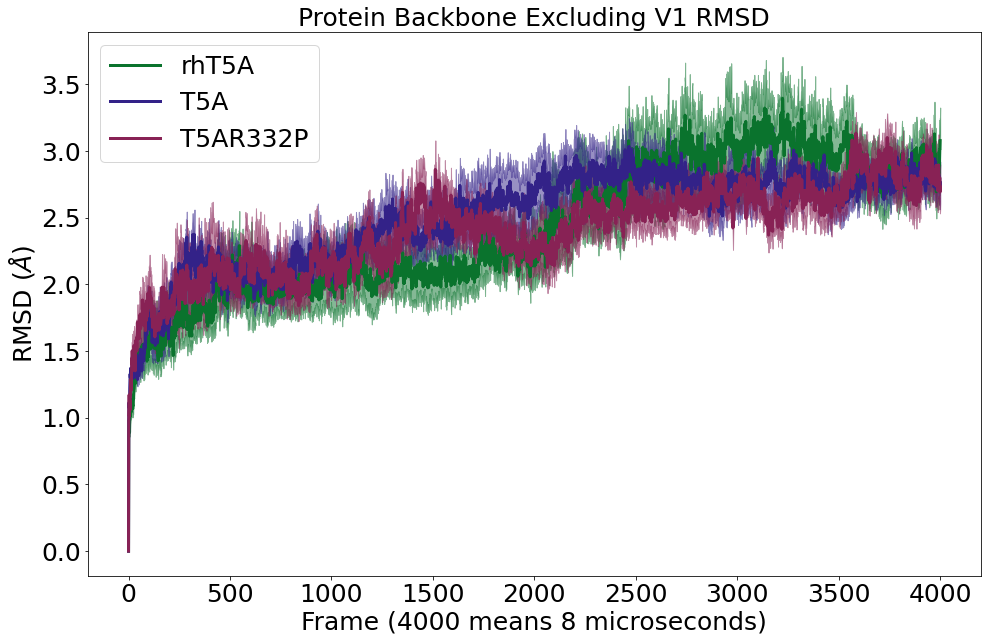

In [34]:
figure(figsize = (16,10))    
plot(mean(bodyrmsds[0],axis = 0),color = colourScheme[0],linewidth = 3,label = system_names[0])
fill_between(arange(4001),mean(bodyrmsds[0],axis = 0)+scipy.stats.sem(bodyrmsds[0],axis = 0),mean(bodyrmsds[0],axis = 0)-scipy.stats.sem(bodyrmsds[0],axis = 0),color = colourScheme[0],alpha = 0.5)

plot(mean(bodyrmsds[1],axis = 0),color = colourScheme[1],linewidth = 3,label = system_names[1])
fill_between(arange(4001),mean(bodyrmsds[1],axis = 0)+scipy.stats.sem(bodyrmsds[1],axis = 0),mean(bodyrmsds[1],axis = 0)-scipy.stats.sem(bodyrmsds[1],axis = 0),color = colourScheme[1],alpha = 0.5)


plot(mean(bodyrmsds[2],axis = 0),color = colourScheme[2],linewidth = 3,label = system_names[2])
fill_between(arange(4001),mean(bodyrmsds[2],axis = 0)+scipy.stats.sem(bodyrmsds[2],axis = 0),mean(bodyrmsds[2],axis = 0)-scipy.stats.sem(bodyrmsds[2],axis = 0),color = colourScheme[2],alpha = 0.5)






xlabel("Frame (4000 means 8 microseconds)",fontsize = 25)
ylabel("RMSD ($\AA$)",fontsize = 25)
title("Protein Backbone Excluding V1 RMSD",fontsize = 25)
xticks(fontsize = 25)
yticks(fontsize = 25)
legend(fontsize = 25)

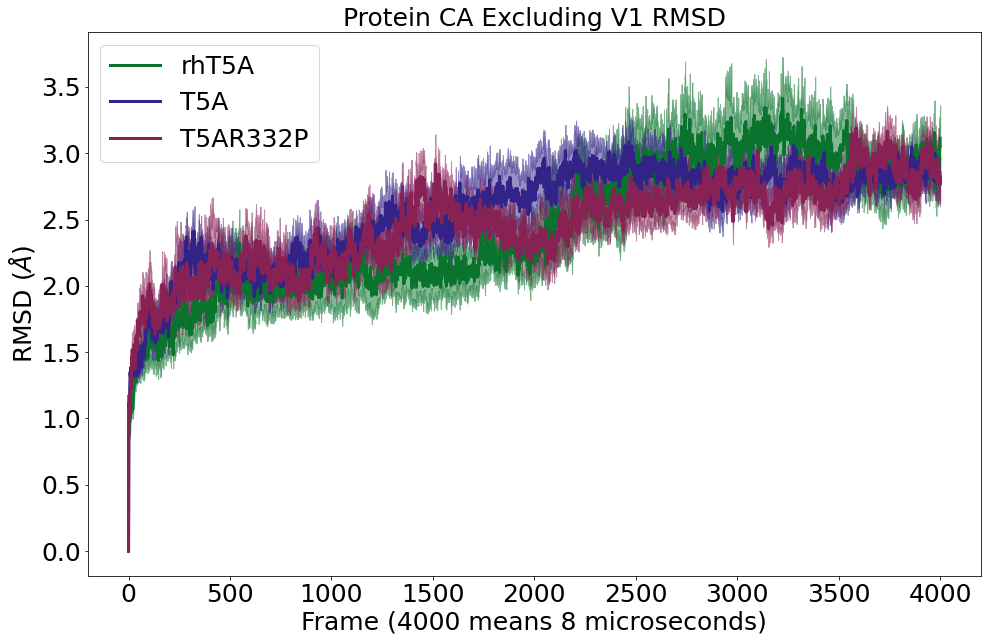

In [37]:
def getRMSD(u,selstring= "backbone"):
    ref = u

    import MDAnalysis.analysis.rms

    R = MDAnalysis.analysis.rms.RMSD(u, ref,
               select=selstring)             # superimpose on whole backbone of the whole protein)                                    # NMP
    R.run()

    rmsd = R.rmsd.T   # transpose makes it easier for plotting
    time = rmsd[1]

    return rmsd[2]

bodyrmsds=[]
for i in range(len(systems)):
    sub=[]
    for j in range(len(systems[i])):
        if i == 0:
            c = colourScheme[0]
        if i==1:
            c = colourScheme[1]
        if i == 2:
            c = colourScheme[2]
            
        sub.append(getRMSD(systems[i][j],"protein and name CA and not ("+system_loop_strings[i]+")"))
        #plot(sub[j],color = c,alpha = 0.3)
    bodyrmsds.append(sub)

figure(figsize = (16,10))    
plot(mean(bodyrmsds[0],axis = 0),color = colourScheme[0],linewidth = 3,label = system_names[0])
fill_between(arange(4001),mean(bodyrmsds[0],axis = 0)+scipy.stats.sem(bodyrmsds[0],axis = 0),mean(bodyrmsds[0],axis = 0)-scipy.stats.sem(bodyrmsds[0],axis = 0),color = colourScheme[0],alpha = 0.5)

plot(mean(bodyrmsds[1],axis = 0),color = colourScheme[1],linewidth = 3,label = system_names[1])
fill_between(arange(4001),mean(bodyrmsds[1],axis = 0)+scipy.stats.sem(bodyrmsds[1],axis = 0),mean(bodyrmsds[1],axis = 0)-scipy.stats.sem(bodyrmsds[1],axis = 0),color = colourScheme[1],alpha = 0.5)


plot(mean(bodyrmsds[2],axis = 0),color = colourScheme[2],linewidth = 3,label = system_names[2])
fill_between(arange(4001),mean(bodyrmsds[2],axis = 0)+scipy.stats.sem(bodyrmsds[2],axis = 0),mean(bodyrmsds[2],axis = 0)-scipy.stats.sem(bodyrmsds[2],axis = 0),color = colourScheme[2],alpha = 0.5)


xlabel("Frame (4000 means 8 microseconds)",fontsize = 25)
ylabel("RMSD ($\AA$)",fontsize = 25)
title("Protein CA Excluding V1 RMSD",fontsize = 25)
xticks(fontsize = 25)
yticks(fontsize = 25)
legend(fontsize = 25)

In [35]:
def getRMSD(u,selstring= "backbone"):
    ref = u

    import MDAnalysis.analysis.rms

    R = MDAnalysis.analysis.rms.RMSD(u, ref,
               select=selstring)             # superimpose on whole backbone of the whole protein)                                    # NMP
    R.run()

    rmsd = R.rmsd.T   # transpose makes it easier for plotting
    time = rmsd[1]

    return rmsd[2]

v1rmsds=[]
for i in range(len(systems)):
    sub=[]
    for j in range(len(systems[i])):
        if i == 0:
            c = colourScheme[0]
        if i==1:
            c = colourScheme[1]
        if i == 2:
            c = colourScheme[2]
            
        sub.append(getRMSD(systems[i][j],"protein and backbone and "+system_loop_strings[i]))
        #plot(sub[j],color = c,alpha = 0.3)
    v1rmsds.append(sub)


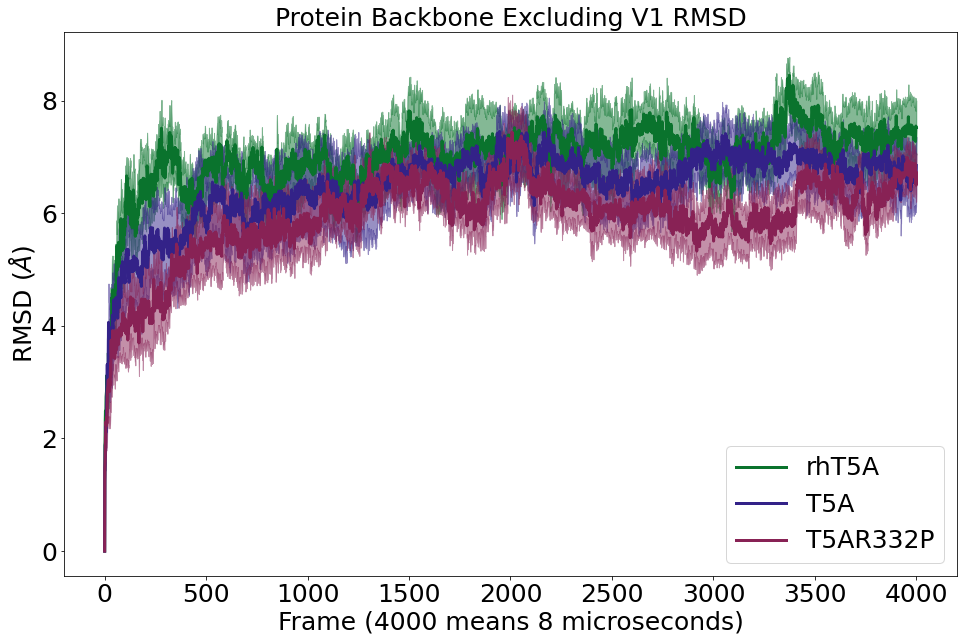

In [36]:
figure(figsize = (16,10))    
plot(mean(v1rmsds[0],axis = 0),color = colourScheme[0],linewidth = 3,label = system_names[0])
fill_between(arange(4001),mean(v1rmsds[0],axis = 0)+scipy.stats.sem(v1rmsds[0],axis = 0),mean(v1rmsds[0],axis = 0)-scipy.stats.sem(v1rmsds[0],axis = 0),color = colourScheme[0],alpha = 0.5)

plot(mean(v1rmsds[1],axis = 0),color = colourScheme[1],linewidth = 3,label = system_names[1])
fill_between(arange(4001),mean(v1rmsds[1],axis = 0)+scipy.stats.sem(v1rmsds[1],axis = 0),mean(v1rmsds[1],axis = 0)-scipy.stats.sem(v1rmsds[1],axis = 0),color = colourScheme[1],alpha = 0.5)


plot(mean(v1rmsds[2],axis = 0),color = colourScheme[2],linewidth = 3,label = system_names[2])
fill_between(arange(4001),mean(v1rmsds[2],axis = 0)+scipy.stats.sem(v1rmsds[2],axis = 0),mean(v1rmsds[2],axis = 0)-scipy.stats.sem(v1rmsds[2],axis = 0),color = colourScheme[2],alpha = 0.5)






xlabel("Frame (4000 means 8 microseconds)",fontsize = 25)
ylabel("RMSD ($\AA$)",fontsize = 25)
title(" V1 Backbone RMSD",fontsize = 25)
xticks(fontsize = 25)
yticks(fontsize = 25)
legend(fontsize = 25)

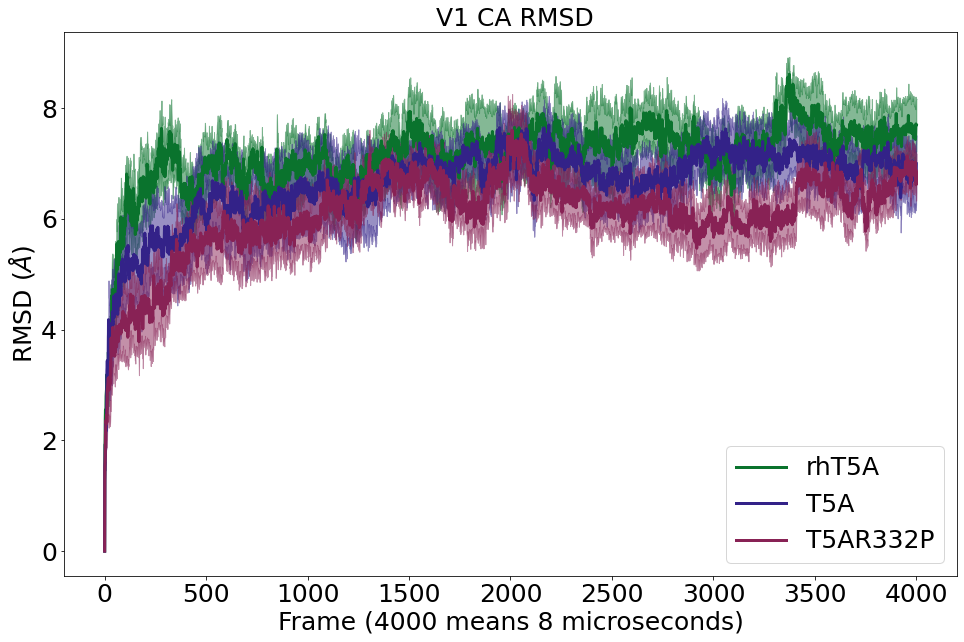

In [38]:
def getRMSD(u,selstring= "backbone"):
    ref = u

    import MDAnalysis.analysis.rms

    R = MDAnalysis.analysis.rms.RMSD(u, ref,
               select=selstring)             # superimpose on whole backbone of the whole protein)                                    # NMP
    R.run()

    rmsd = R.rmsd.T   # transpose makes it easier for plotting
    time = rmsd[1]

    return rmsd[2]

v1rmsds=[]
for i in range(len(systems)):
    sub=[]
    for j in range(len(systems[i])):
        if i == 0:
            c = colourScheme[0]
        if i==1:
            c = colourScheme[1]
        if i == 2:
            c = colourScheme[2]
            
        sub.append(getRMSD(systems[i][j],"protein and name CA and "+system_loop_strings[i]))
        #plot(sub[j],color = c,alpha = 0.3)
    v1rmsds.append(sub)
figure(figsize = (16,10))    
plot(mean(v1rmsds[0],axis = 0),color = colourScheme[0],linewidth = 3,label = system_names[0])
fill_between(arange(4001),mean(v1rmsds[0],axis = 0)+scipy.stats.sem(v1rmsds[0],axis = 0),mean(v1rmsds[0],axis = 0)-scipy.stats.sem(v1rmsds[0],axis = 0),color = colourScheme[0],alpha = 0.5)

plot(mean(v1rmsds[1],axis = 0),color = colourScheme[1],linewidth = 3,label = system_names[1])
fill_between(arange(4001),mean(v1rmsds[1],axis = 0)+scipy.stats.sem(v1rmsds[1],axis = 0),mean(v1rmsds[1],axis = 0)-scipy.stats.sem(v1rmsds[1],axis = 0),color = colourScheme[1],alpha = 0.5)


plot(mean(v1rmsds[2],axis = 0),color = colourScheme[2],linewidth = 3,label = system_names[2])
fill_between(arange(4001),mean(v1rmsds[2],axis = 0)+scipy.stats.sem(v1rmsds[2],axis = 0),mean(v1rmsds[2],axis = 0)-scipy.stats.sem(v1rmsds[2],axis = 0),color = colourScheme[2],alpha = 0.5)






xlabel("Frame (4000 means 8 microseconds)",fontsize = 25)
ylabel("RMSD ($\AA$)",fontsize = 25)
title(" V1 CA RMSD",fontsize = 25)
xticks(fontsize = 25)
yticks(fontsize = 25)
legend(fontsize = 25)

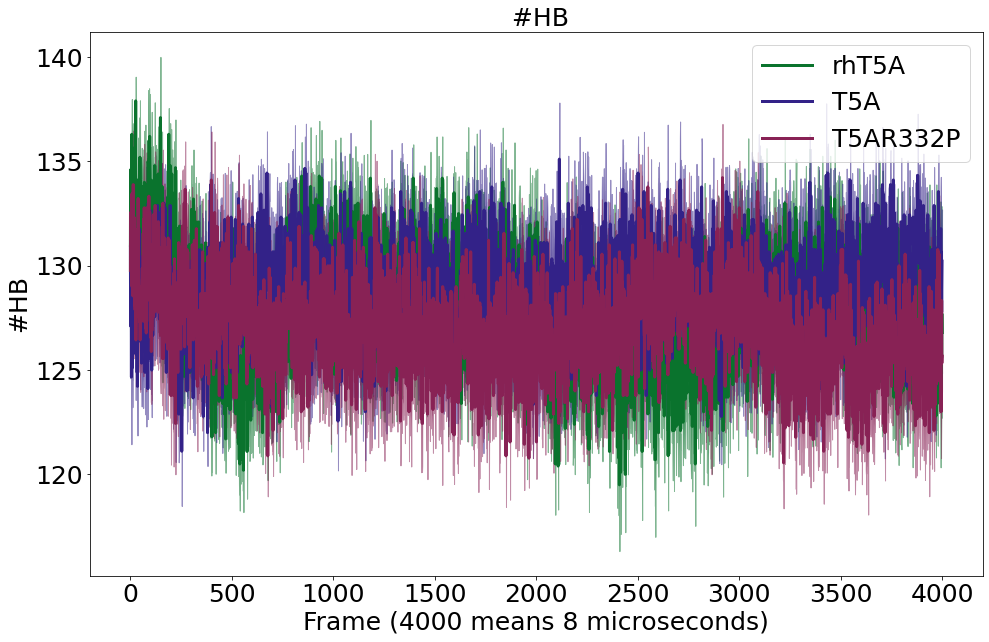

In [79]:
systemhbFiles=[]
for i in range(len(systemFolders)):
    systemhbFiles.append(sorted(glob.glob(systemFolders[i]+"hb*.xvg")))
allhbs=[]
for i in range(len(systemhbFiles)):
    sub = []
    for j in range(len(systemhbFiles[i])):
        sub.append(loadtxt(systemhbFiles[i][j],skiprows = 25,unpack = True)[1])
    allhbs.append(sub)
    
    
figure(figsize = (16,10))    
plot(mean(allhbs[0],axis = 0),color = colourScheme[0],linewidth = 3,label = system_names[0])
fill_between(arange(4001),mean(allhbs[0],axis = 0)+scipy.stats.sem(allhbs[0],axis = 0),mean(allhbs[0],axis = 0)-scipy.stats.sem(allhbs[0],axis = 0),color = colourScheme[0],alpha = 0.5)

plot(mean(allhbs[1],axis = 0),color = colourScheme[1],linewidth = 3,label = system_names[1])
fill_between(arange(4001),mean(allhbs[1],axis = 0)+scipy.stats.sem(allhbs[1],axis = 0),mean(allhbs[1],axis = 0)-scipy.stats.sem(allhbs[1],axis = 0),color = colourScheme[1],alpha = 0.5)


plot(mean(allhbs[2],axis = 0),color = colourScheme[2],linewidth = 3,label = system_names[2])
fill_between(arange(4001),mean(allhbs[2],axis = 0)+scipy.stats.sem(allhbs[2],axis = 0),mean(allhbs[2],axis = 0)-scipy.stats.sem(allhbs[2],axis = 0),color = colourScheme[2],alpha = 0.5)






xlabel("Frame (4000 means 8 microseconds)",fontsize = 25)
ylabel("#HB",fontsize = 25)
title(" #HB",fontsize = 25)
xticks(fontsize = 25)
yticks(fontsize = 25)
legend(fontsize = 25)

In [80]:
#IF YOU NEED TO COMPUTE THE RAW DATA THEN SWITCH THIS TO TRUE (NOOTE THAT IT TAKES QUITE A LONG TIME)
needRaw = True

if needRaw == True:
    def computeHbonds(i,j,tu):

        #hba1=HBA(tu,between = ["protein","protein"],d_a_cutoff =3)
        #hba1.hydrogens_sel = hba1.guess_hydrogens("all")
        #hba1.acceptors_sel = hba1.guess_acceptors("all") #DO NOT GUESS DONORS IF YOU HAVE BOND INFORMATION (we do)
        #results1=hba1.run()
        ###save("raw_hbonds_cutoff3_"+str(i)+"_"+str(j)+"joblib.npy",results1.hbonds)

        hba2=HBA(tu,between = ["protein","protein"],d_a_cutoff =3.5)
        hba2.hydrogens_sel = hba2.guess_hydrogens("all")
        hba2.acceptors_sel = hba2.guess_acceptors("all") #DO NOT GUESS DONORS IF YOU HAVE BOND INFORMATION (we do)
        results2=hba2.run()
        save("raw_hbonds_cutoff3d5_"+str(i)+"_"+str(j)+".npy",results2.hbonds)

        return results2


    t1 = time.time()
    hbondarrays=[]
    for i in range(len(systems)):
        sub=[]
        for j in range(len(systems[i])):
            sub.append(computeHbonds(i,j,systems[i][j]))
        hbondarrays.append(sub)


C:\Users\Liam\anaconda3\envs\mda2\lib\site-packages\MDAnalysis\analysis\hydrogenbonds\hbond_analysis.py:672: DeprecationWarning: The `hbonds` attribute was deprecated in MDAnalysis 2.0.0 and will be removed in MDAnalysis 3.0.0. Please use `results.hbonds` instead.
  warnings.warn(wmsg, DeprecationWarning)


In [ ]:
hbondDFs=[]
for i in range(len(allhbondarrays)):
    sub=[]
    for j in range(len(allhbondarrays[i])):
        tdf=pd.DataFrame(allhbondarrays[i][j],columns=["frame","donorid","hid","acceptorid","distance","angle"])
        tu = systems[i][j]

        atomid_to_resid=dict(zip(tu.atoms.ids,tu.atoms.resids))

        tdf["donor_resid"] = tdf["donorid"].map(atomid_to_resid)
        tdf["acceptor_resid"] = tdf["acceptorid"].map(atomid_to_resid)

        resid_to_resname=dict(zip(tu.residues.resids,tu.residues.resnames))

        tdf["donor_resname"] = tdf["donor_resid"].map(resid_to_resname)
        tdf["acceptor_resname"] = tdf["acceptor_resid"].map(resid_to_resname)
        
        sub.append(tdf)
    hbondDFs.append(sub)